<a href="https://colab.research.google.com/github/osbornjunior015-sys/dp-fraud-detection/blob/master/FRAUD_DETECTION_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [ ]:
df = pd.read_csv('/content/fraud_data.csv.csv')

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.shape

(151799, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151799 entries, 0 to 151798
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            151799 non-null  int64  
 1   type            151799 non-null  object 
 2   amount          151799 non-null  float64
 3   nameOrig        151799 non-null  object 
 4   oldbalanceOrg   151799 non-null  float64
 5   newbalanceOrig  151798 non-null  float64
 6   nameDest        151798 non-null  object 
 7   oldbalanceDest  151798 non-null  float64
 8   newbalanceDest  151798 non-null  float64
 9   isFraud         151798 non-null  float64
 10  isFlaggedFraud  151798 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 12.7+ MB


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,151667
1.0,131


In [ ]:
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0.0,151798


In [ ]:
df.isnull().sum().sum()

np.int64(6)

In [ ]:
df.shape[0]

151799

In [ ]:
round((df['isFraud'].value_counts()[1] / df.shape[0])*100,3)

np.float64(0.086)

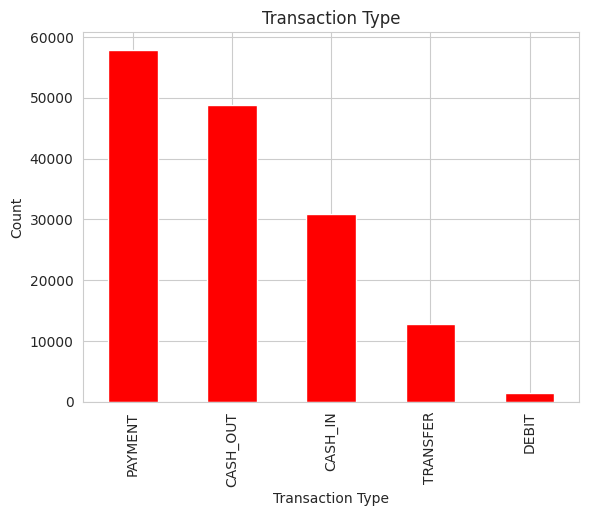

In [ ]:
df["type"].value_counts().plot(kind="bar", title="Transaction Type", color = "red")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [ ]:
fraud_by_type

,isFraud
type,
TRANSFER,0.005058
CASH_OUT,0.001351
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


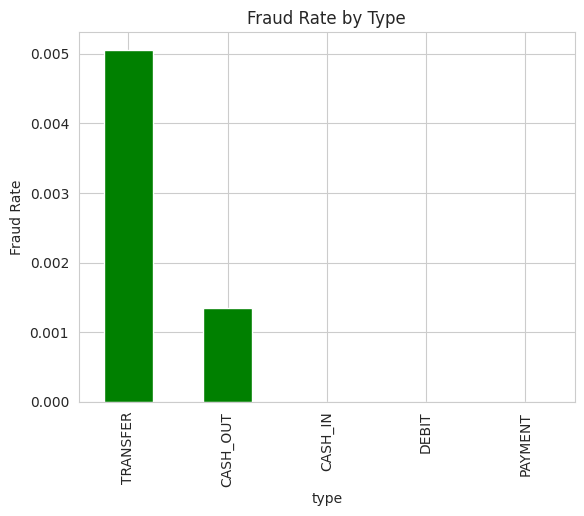

In [ ]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color = "green")
plt.ylabel("Fraud Rate")
plt.show()

In [ ]:
df["amount"].describe().astype(int)

,amount
count,151799
mean,179177
std,340160
min,0
25%,11113
50%,61226
75%,223039
max,10000000


<function matplotlib.pyplot.show(close=None, block=None)>

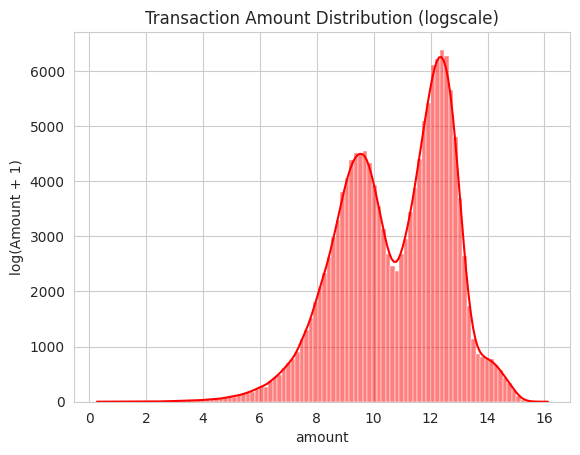

In [ ]:
sns.histplot(np.log1p(df["amount"]), bins= 100, kde =True, color="red")
plt.title("Transaction Amount Distribution (logscale)")
plt.ylabel("log(Amount + 1)")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

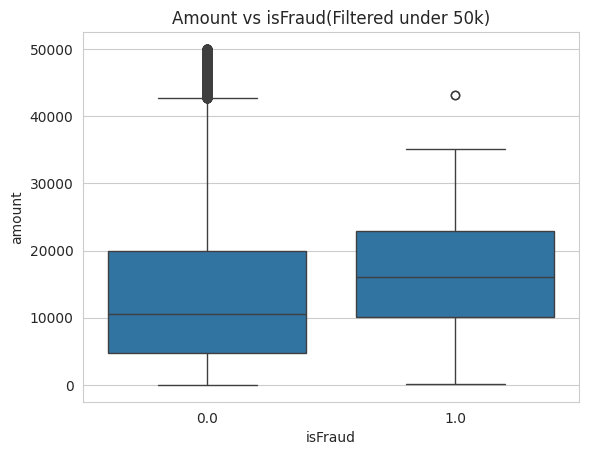

In [ ]:
sns.boxplot(data= df[df["amount"] < 50000], x= "isFraud", y= "amount")
plt.title("Amount vs isFraud(Filtered under 50k)")
plt.show


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["oldbalanceDest"] - df["newbalanceDest"]

In [ ]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(30795)

In [ ]:
(df["balanceDiffDest"] < 0).sum()

np.int64(63090)

In [ ]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


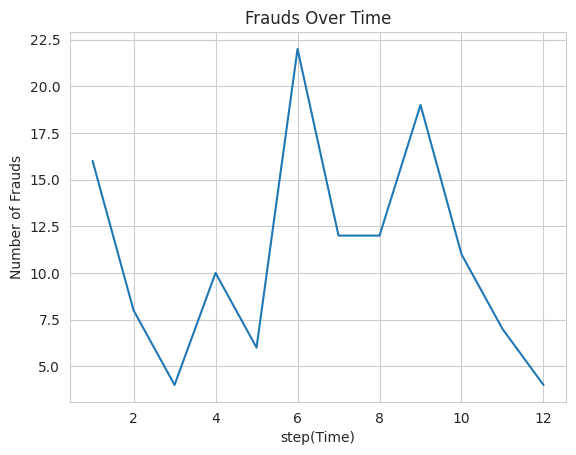

In [ ]:
frauds_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_step.index , frauds_per_step.values, label="frauds per step")
plt.xlabel("step(Time)")
plt.ylabel("Number of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [ ]:
df.drop(columns="step", inplace = True)

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [ ]:
top_senders = df["nameOrig"].value_counts().head(10)

In [ ]:
top_senders

,count
nameOrig,
C260230637,2
C44568807,2
C1709295811,2
C2064614971,1
C71897745,1
C1831903030,1
C2016722550,1
C883291771,1
C1284955877,1


In [ ]:
top_receivers = df["nameDest"].value_counts().head(10)

In [ ]:
top_receivers

,count
nameDest,
C985934102,80
C1286084959,79
C1590550415,74
C248609774,74
C2083562754,71
C977993101,68
C665576141,67
C1360767589,64
C451111351,63


In [ ]:
fraud_users = df[df["isFraud"]== 1]["nameOrig"].value_counts().head(10)

In [ ]:
fraud_users

,count
nameOrig,
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C137533655,1
C1118430673,1
C749981943,1
C1334405552,1
C467632528,1


In [ ]:
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

In [ ]:
fraud_types["type"].value_counts()

,count
type,
CASH_OUT,48858
TRANSFER,12851


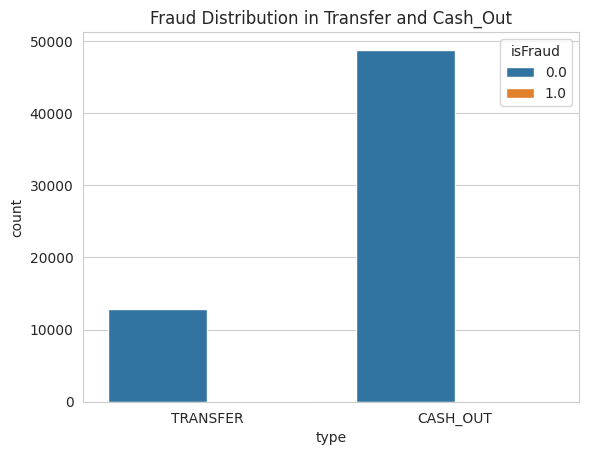

In [ ]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer and Cash_Out")
plt.show()

In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [ ]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

In [ ]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.017958,-0.023204,0.229916,0.356693,0.036440
oldbalanceOrg,-0.017958,1.000000,0.998955,0.096676,0.065992,-0.003055
newbalanceOrig,-0.023204,0.998955,1.000000,0.098159,0.064911,-0.009078
oldbalanceDest,0.229916,0.096676,0.098159,1.000000,0.947677,-0.008401
newbalanceDest,0.356693,0.065992,0.064911,0.947677,1.000000,-0.005379
isFraud,0.036440,-0.003055,-0.009078,-0.008401,-0.005379,1.000000


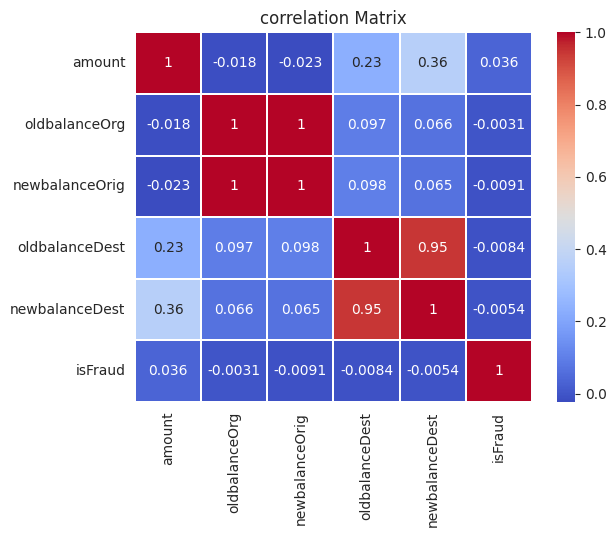

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths= 0.05)
plt.title("correlation Matrix")
plt.show()

In [ ]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]

In [ ]:
len(zero_after_transfer)

24335

In [ ]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1.0,0.0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1.0,0.0,181.0,21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0.0,0.0,15325.0,-46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0.0,0.0,705.0,22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0.0,0.0,10835.0,-2712905.89


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [ ]:
df_model = df.drop(["nameOrig","nameDest","isFlaggedFraud"], axis = 1)

In [ ]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


In [ ]:
Categorical = ["type"]
Numeric = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [ ]:
y = df_model["isFraud"]
X = df_model.drop(["isFraud"], axis=1)

In [ ]:
df_model_cleaned = df_model.dropna(subset=['isFraud'])
y = df_model_cleaned["isFraud"]
X = df_model_cleaned.drop(["isFraud"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y )

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), Numeric),
        ("cat", OneHotEncoder(drop="first"), Categorical)
    ],
    remainder="drop"
)

In [ ]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.84      0.92     45501
         1.0       0.00      0.90      0.01        39

    accuracy                           0.84     45540
   macro avg       0.50      0.87      0.46     45540
weighted avg       1.00      0.84      0.91     45540



In [ ]:
print(confusion_matrix(y_test,y_pred))

[[38389  7112]
 [    4    35]]


In [ ]:
pipeline.score(X_test,y_test)*100

84.3741765480896

In [ ]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipelie.pkl")

['fraud_detection_pipelie.pkl']

First, let's confirm the files in your `/content/` directory. You should see `fraud_detection_app.py`.

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 50.4 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("/content/fraud_detection_pipelie.pkl")

st.title("Fraud Detection Prediction App")
st.markdown("Please enter the transaction details and use the prediction button")

st.divider()

transaction_type = st.selectbox("Transaction type", ["PAYMENT", "TRANSFER", "CASH_OUT", "DEPOSIT"])
amount = st.number_input("Amount", min_value = 0.0, value = 1000.0)
OldbalanceOrg = st.number_input("Old Balance(Sender)", min_value = 0.0, value = 10000.0)
newbalanceOrig = st.number_input("New Balance(Sender)", min_value = 0.0, value = 9000.0)
OldbalanceDest = st.number_input("Old Balance(Receiver)", min_value = 0.0, value = 0.0)
newbalanceDest = st.number_input("New Balance(Receiver)", min_value = 0.0, value = 0.00)

if st.button("predict"):
  input_data = pd.DataFrame([{
    "type" : transaction_type,
    "amount" : amount,
    "oldbalanceOrg" : OldbalanceOrg,
    "newbalanceOrig" : newbalanceOrig,
    "oldbalanceDest" : OldbalanceDest,
    "newbalanceDest" : newbalanceDest
  }])



  prediction = model.predict(input_data)[0]

  st.subheader(f"Prediction : '{int(prediction)}'")

  if prediction == 1:
    st.error("This transaction can be fraud")
  else:
    st.success("This transaction looks like it is not a fraud")

2026-05-03 18:52:24.922 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 18:52:25.134 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-03 18:52:25.135 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 18:52:25.138 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 18:52:25.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 18:52:25.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 18:52:25.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 18:52:25.144 Thread 'MainThread': mi

Now, run your Streamlit application using the correct file name `fraud_detection_app.py`. This command will also install `localtunnel` and provide a public URL to access your app. Click on the public URL that appears in the output.

In [ ]:
!npm install localtunnel

⠙⠹⠸⠼⠴
up to date, audited 23 packages in 852ms
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠦

In [ ]:
!streamlit run fraud_detection_app.py & npx localtunnel --port 8501

⠙Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: fraud_detection_app.py
your url is: https://twenty-places-fix.loca.lt
